In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def fitness_function(x):
    return np.sum(x ** 2)  # Sphere function


In [3]:
population_size = 20
dimensions = 5
clone_factor = 5
mutation_rate = 0.1
iterations = 50
bounds = (-10, 10)


In [4]:
def initialize_population():
    return np.random.uniform(bounds[0], bounds[1], 
                             (population_size, dimensions))


In [5]:
def clonal_selection():
    population = initialize_population()
    best_fitness_history = []

    for iteration in range(iterations):
        # Evaluate fitness
        fitness = np.array([fitness_function(ind) for ind in population])
        
        # Sort by fitness (lower is better)
        sorted_indices = np.argsort(fitness)
        population = population[sorted_indices]
        fitness = fitness[sorted_indices]

        best_fitness_history.append(fitness[0])

        # Select best antibodies
        selected = population[:population_size // 2]

        # Clone and mutate
        clones = []
        for antibody in selected:
            for _ in range(clone_factor):
                clone = antibody + mutation_rate * np.random.randn(dimensions)
                clone = np.clip(clone, bounds[0], bounds[1])
                clones.append(clone)

        clones = np.array(clones)

        # Evaluate clones
        clone_fitness = np.array([fitness_function(c) for c in clones])

        # Replace worst antibodies
        combined_population = np.vstack((population, clones))
        combined_fitness = np.hstack((fitness, clone_fitness))

        best_indices = np.argsort(combined_fitness)[:population_size]
        population = combined_population[best_indices]

    return population[0], best_fitness_history


In [6]:
best_solution, fitness_history = clonal_selection()

print("Best Solution:", best_solution)
print("Best Fitness:", fitness_function(best_solution))


Best Solution: [-0.49435191  0.18862949  0.28811247  0.02317444 -0.55990369]
Best Fitness: 0.6770028892112079


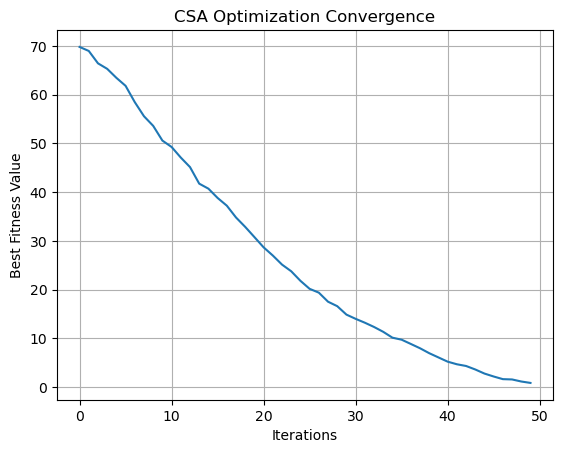

In [7]:
plt.plot(fitness_history)
plt.xlabel("Iterations")
plt.ylabel("Best Fitness Value")
plt.title("CSA Optimization Convergence")
plt.grid()
plt.show()
